#Mounting Google Drive & Loading the paths

In [ ]:
import os
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')

BASE_DIR = "/content/drive/MyDrive/Emotion_Recognition_Thesis"

RESULT_DIR = os.path.join(BASE_DIR, "results")
MODEL_DIR = os.path.join(BASE_DIR, "models")
SPLIT_DIR = os.path.join(RESULT_DIR, "dataset_splits")

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cuda


#Loading the saved splits

In [ ]:
train_df = pd.read_csv(
    os.path.join(
        SPLIT_DIR,
        "affectnet_train.csv"
    )
)

val_df = pd.read_csv(
    os.path.join(
        SPLIT_DIR,
        "affectnet_validation.csv"
    )
)

test_df = pd.read_csv(
    os.path.join(
        SPLIT_DIR,
        "affectnet_test.csv"
    )
)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 13691
Validation: 2417
Test: 14518


In [ ]:
EMOTION_CLASSES = [
    "anger",
    "contempt",
    "disgust",
    "fear",
    "happy",
    "neutral",
    "sad",
    "surprise"
]

NUM_CLASSES = len(EMOTION_CLASSES)

idx_to_class = {
    i: emotion
    for i, emotion in enumerate(
        EMOTION_CLASSES
    )
}

#Recreating dataset & Evaluation transform

In [ ]:
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

class FacialEmotionDataset(Dataset):

    def __init__(
        self,
        dataframe,
        transform=None
    ):
        self.dataframe = dataframe.reset_index(
            drop=True
        )
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):

        row = self.dataframe.iloc[index]

        image = Image.open(
            row["path"]
        ).convert("RGB")

        label = int(row["label"])

        if self.transform:
            image = self.transform(image)

        return image, label

#Validation & Test Loaders

In [ ]:
val_dataset = FacialEmotionDataset(
    val_df,
    transform=eval_transform
)

test_dataset = FacialEmotionDataset(
    test_df,
    transform=eval_transform
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

#Defining one evaluation function for every model

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

def evaluate_model(
    model,
    loader,
    device
):

    model.eval()

    y_true = []
    y_pred = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)

            outputs = model(images)

            predictions = outputs.argmax(
                dim=1
            )

            y_true.extend(
                labels.numpy()
            )

            y_pred.extend(
                predictions.cpu().numpy()
            )

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    precision = precision_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    macro_f1 = f1_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "macro_f1": macro_f1,
        "y_true": y_true,
        "y_pred": y_pred
    }

#Loading best fine-tuned ResNet50

In [ ]:
from torch import nn
from torchvision.models import (
    resnet50,
    ResNet50_Weights
)

resnet_model = resnet50(
    weights=None
)

resnet_model.fc = nn.Linear(
    resnet_model.fc.in_features,
    NUM_CLASSES
)

checkpoint_path = os.path.join(
    MODEL_DIR,
    "resnet50_finetuned_best.pth"
)

resnet_model.load_state_dict(
    torch.load(
        checkpoint_path,
        map_location=device
    )
)

resnet_model = resnet_model.to(device)

print("Fine-tuned ResNet50 loaded.")

Fine-tuned ResNet50 loaded.


#Evaluating the untouched AffectNet test set:

In [ ]:
resnet_test_results = evaluate_model(
    resnet_model,
    test_loader,
    device
)

print(
    "Accuracy:",
    round(
        resnet_test_results["accuracy"],
        4
    )
)

print(
    "Macro Precision:",
    round(
        resnet_test_results["precision"],
        4
    )
)

print(
    "Macro Recall:",
    round(
        resnet_test_results["recall"],
        4
    )
)

print(
    "Macro F1:",
    round(
        resnet_test_results["macro_f1"],
        4
    )
)

Accuracy: 0.5753
Macro Precision: 0.5541
Macro Recall: 0.5326
Macro F1: 0.5237


#Classification Report

In [ ]:
from sklearn.metrics import classification_report

report = classification_report(
    resnet_test_results["y_true"],
    resnet_test_results["y_pred"],
    target_names=EMOTION_CLASSES,
    digits=4,
    zero_division=0
)

print(report)

              precision    recall  f1-score   support

       anger     0.5232    0.3091    0.3886      1718
    contempt     0.5498    0.5046    0.5262      1312
     disgust     0.4319    0.2973    0.3522      1248
        fear     0.6044    0.2975    0.3987      1664
       happy     0.8522    0.8402    0.8462      2704
     neutral     0.6811    0.8910    0.7720      2368
         sad     0.3867    0.7184    0.5028      1584
    surprise     0.4039    0.4026    0.4032      1920

    accuracy                         0.5753     14518
   macro avg     0.5541    0.5326    0.5237     14518
weighted avg     0.5834    0.5753    0.5612     14518



#Confusion Matrix

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    resnet_test_results["y_true"],
    resnet_test_results["y_pred"]
)

print(cm)

[[ 531  206  212   54    1    1  545  168]
 [  85  662   53   12   33   67  271  129]
 [ 171   98  371   42   24   24  371  147]
 [  82   51   93  495    2    4  376  561]
 [   0    1    1    0 2272  421    7    2]
 [   2    1    0    2  240 2110    9    4]
 [  85  110   74   46    0    1 1138  130]
 [  59   75   55  168   94  470  226  773]]


In [ ]:
cm_normalized = confusion_matrix(
    resnet_test_results["y_true"],
    resnet_test_results["y_pred"],
    normalize="true"
)

print(
    np.round(
        cm_normalized,
        3
    )
)

[[0.309 0.12  0.123 0.031 0.001 0.001 0.317 0.098]
 [0.065 0.505 0.04  0.009 0.025 0.051 0.207 0.098]
 [0.137 0.079 0.297 0.034 0.019 0.019 0.297 0.118]
 [0.049 0.031 0.056 0.297 0.001 0.002 0.226 0.337]
 [0.    0.    0.    0.    0.84  0.156 0.003 0.001]
 [0.001 0.    0.    0.001 0.101 0.891 0.004 0.002]
 [0.054 0.069 0.047 0.029 0.    0.001 0.718 0.082]
 [0.031 0.039 0.029 0.088 0.049 0.245 0.118 0.403]]


* The biggest issue is that the model is over-attracted to certain classes, especially sad and neutral.

#Calculating the Class weights

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

train_labels = train_df["label"].values

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(NUM_CLASSES),
    y=train_labels
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32
).to(device)

print("Class weights:")

for emotion, weight in zip(
    EMOTION_CLASSES,
    class_weights.cpu().numpy()
):
    print(
        f"{emotion:10s}: {weight:.4f}"
    )

Class weights:
anger     : 1.3423
contempt  : 1.2916
disgust   : 1.6377
fear      : 1.3318
happy     : 0.8604
neutral   : 0.7301
sad       : 0.6515
surprise  : 0.9502


#Creating weighted loss

In [ ]:
weighted_criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

print(weighted_criterion)

CrossEntropyLoss()


#Reloading the best RestNet

In [ ]:
from torchvision.models import resnet50

weighted_resnet = resnet50(
    weights=None
)

weighted_resnet.fc = nn.Linear(
    weighted_resnet.fc.in_features,
    NUM_CLASSES
)

weighted_resnet.load_state_dict(
    torch.load(
        os.path.join(
            MODEL_DIR,
            "resnet50_finetuned_best.pth"
        ),
        map_location=device
    )
)

weighted_resnet = weighted_resnet.to(device)

print("Best ResNet50 checkpoint loaded.")

Best ResNet50 checkpoint loaded.


#Freezing everything

In [ ]:
for param in weighted_resnet.parameters():
    param.requires_grad = False

#Unfreezing layer4 & Classifier

In [ ]:
for param in weighted_resnet.layer4.parameters():
    param.requires_grad = True

for param in weighted_resnet.fc.parameters():
    param.requires_grad = True

#Optimizer

In [ ]:
weighted_optimizer = torch.optim.AdamW(
    filter(
        lambda p: p.requires_grad,
        weighted_resnet.parameters()
    ),
    lr=5e-6,
    weight_decay=1e-4
)

#Training Transformation

In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
train_dataset = FacialEmotionDataset(
    train_df,
    transform=train_transform
)

print("Training images:", len(train_dataset))

Training images: 13691


In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

print("Number of training batches:", len(train_loader))

Number of training batches: 428


In [ ]:
images, labels = next(iter(train_loader))

print("Images:", images.shape)
print("Labels:", labels.shape)

Images: torch.Size([32, 3, 224, 224])
Labels: torch.Size([32])


In [ ]:
from tqdm.auto import tqdm

def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device
):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(
        loader,
        leave=False
    ):

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        predictions = outputs.argmax(
            dim=1
        )

        correct += (
            predictions == labels
        ).sum().item()

        total += labels.size(0)

    average_loss = (
        running_loss /
        len(loader)
    )

    accuracy = (
        correct /
        total
    )

    return average_loss, accuracy

In [ ]:
def validate(
    model,
    loader,
    criterion,
    device
):

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            running_loss += loss.item()

            predictions = outputs.argmax(
                dim=1
            )

            correct += (
                predictions == labels
            ).sum().item()

            total += labels.size(0)

    average_loss = (
        running_loss /
        len(loader)
    )

    accuracy = (
        correct /
        total
    )

    return average_loss, accuracy

In [ ]:
def train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    epochs,
    model_name,
    patience=3
):

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    best_val_loss = float("inf")
    patience_counter = 0

    checkpoint_path = os.path.join(
        MODEL_DIR,
        f"{model_name}_best.pth"
    )

    for epoch in range(epochs):

        train_loss, train_acc = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            device
        )

        val_loss, val_acc = validate(
            model,
            val_loader,
            criterion,
            device
        )

        history["train_loss"].append(
            train_loss
        )

        history["train_acc"].append(
            train_acc
        )

        history["val_loss"].append(
            val_loss
        )

        history["val_acc"].append(
            val_acc
        )

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_acc:.4f}"
        )

        if val_loss < best_val_loss:

            best_val_loss = val_loss
            patience_counter = 0

            torch.save(
                model.state_dict(),
                checkpoint_path
            )

            print(
                f"Saved best model: "
                f"{checkpoint_path}"
            )

        else:

            patience_counter += 1

            if patience_counter >= patience:

                print(
                    "Early stopping triggered."
                )

                break

    return history

In [ ]:
print("Device:", device)

print(
    "Train batches:",
    len(train_loader)
)

print(
    "Validation batches:",
    len(val_loader)
)

print(
    "Test batches:",
    len(test_loader)
)

print(
    "Training functions ready:",
    callable(train_model)
)

Device: cuda
Train batches: 428
Validation batches: 76
Test batches: 454
Training functions ready: True


In [ ]:
weighted_history = train_model(
    model=weighted_resnet,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=weighted_criterion,
    optimizer=weighted_optimizer,
    epochs=5,
    model_name="resnet50_weighted",
    patience=3
)

  0%|          | 0/428 [00:00<?, ?it/s]

Epoch 1/5 | Train Loss: 0.9495 | Train Acc: 0.6758 | Val Loss: 1.1623 | Val Acc: 0.5780
Saved best model: /content/drive/MyDrive/Emotion_Recognition_Thesis/models/resnet50_weighted_best.pth


  0%|          | 0/428 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x784f4dd42700>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x784f4dd42700>    self._shutdown_workers()
Traceback (most recent call last):

  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
        self._shutdown_workers()if w.is_alive():

  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
        if w.is_alive():assert self._parent_pid == os.getpid(), 'can only test a child process'

  File "/usr/lib/python3.13/multiprocessing/process.py", line 1

Epoch 2/5 | Train Loss: 0.9220 | Train Acc: 0.6768 | Val Loss: 1.1618 | Val Acc: 0.5805
Saved best model: /content/drive/MyDrive/Emotion_Recognition_Thesis/models/resnet50_weighted_best.pth


...

  0%|          | 0/428 [00:00<?, ?it/s]

Epoch 4/5 | Train Loss: 0.8994 | Train Acc: 0.6838 | Val Loss: 1.1583 | Val Acc: 0.5825


  0%|          | 0/428 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x784f4dd42700>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
Exception ignored in:   File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
<function _MultiProcessingDataLoaderIter.__del__ at 0x784f4dd42700>
    if w.is_alive():Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__

      File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
self._shutdown_workers()    
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
assert self._parent_pid == os.getpid(), 'can only test a child process'    
if w.is_alive():AssertionError
:   File "/usr/lib/python3.13/multiprocessing/pro

Epoch 5/5 | Train Loss: 0.8840 | Train Acc: 0.6918 | Val Loss: 1.1507 | Val Acc: 0.5780
Saved best model: /content/drive/MyDrive/Emotion_Recognition_Thesis/models/resnet50_weighted_best.pth


In [ ]:
weighted_resnet.load_state_dict(
    torch.load(
        os.path.join(
            MODEL_DIR,
            "resnet50_weighted_best.pth"
        ),
        map_location=device
    )
)

<All keys matched successfully>

In [ ]:
weighted_results = evaluate_model(
    weighted_resnet,
    test_loader,
    device
)

print(
    "Accuracy:",
    round(weighted_results["accuracy"], 4)
)

print(
    "Macro Precision:",
    round(weighted_results["precision"], 4)
)

print(
    "Macro Recall:",
    round(weighted_results["recall"], 4)
)

print(
    "Macro F1:",
    round(weighted_results["macro_f1"], 4)
)

Accuracy: 0.5955
Macro Precision: 0.5552
Macro Recall: 0.5582
Macro F1: 0.5519


In [ ]:
print(
    classification_report(
        weighted_results["y_true"],
        weighted_results["y_pred"],
        target_names=EMOTION_CLASSES,
        digits=4,
        zero_division=0
    )
)

              precision    recall  f1-score   support

       anger     0.5027    0.3772    0.4310      1718
    contempt     0.5135    0.5945    0.5510      1312
     disgust     0.4089    0.4062    0.4076      1248
        fear     0.5512    0.4008    0.4642      1664
       happy     0.8424    0.8658    0.8539      2704
     neutral     0.6910    0.8801    0.7741      2368
         sad     0.5023    0.5619    0.5304      1584
    surprise     0.4300    0.3792    0.4030      1920

    accuracy                         0.5955     14518
   macro avg     0.5552    0.5582    0.5519     14518
weighted avg     0.5855    0.5955    0.5855     14518



#Weighted confusion matrix

In [ ]:
from sklearn.metrics import confusion_matrix

weighted_cm = confusion_matrix(
    weighted_results["y_true"],
    weighted_results["y_pred"]
)

weighted_cm_normalized = confusion_matrix(
    weighted_results["y_true"],
    weighted_results["y_pred"],
    normalize="true"
)

print(
    np.round(
        weighted_cm_normalized,
        3
    )
)

[[0.377 0.155 0.161 0.055 0.    0.002 0.169 0.081]
 [0.078 0.595 0.059 0.024 0.027 0.052 0.08  0.085]
 [0.161 0.098 0.406 0.049 0.022 0.018 0.146 0.101]
 [0.075 0.042 0.084 0.401 0.001 0.002 0.116 0.279]
 [0.    0.001 0.    0.    0.866 0.132 0.001 0.   ]
 [0.    0.    0.    0.001 0.117 0.88  0.001 0.001]
 [0.091 0.104 0.097 0.068 0.    0.003 0.562 0.076]
 [0.035 0.06  0.044 0.129 0.051 0.247 0.056 0.379]]


#Plotting the matrix

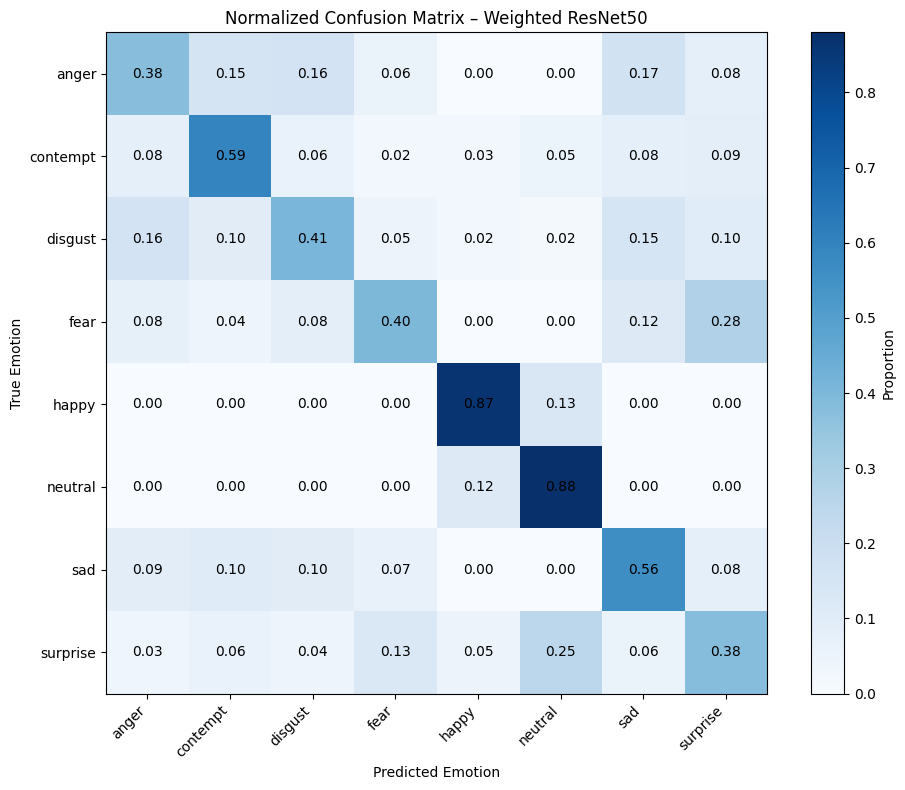

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(
    figsize=(10, 8)
)

im = ax.imshow(
    weighted_cm_normalized,
    cmap="Blues"
)

ax.set_xticks(
    np.arange(NUM_CLASSES)
)

ax.set_yticks(
    np.arange(NUM_CLASSES)
)

ax.set_xticklabels(
    EMOTION_CLASSES,
    rotation=45,
    ha="right"
)

ax.set_yticklabels(
    EMOTION_CLASSES
)

ax.set_xlabel(
    "Predicted Emotion"
)

ax.set_ylabel(
    "True Emotion"
)

ax.set_title(
    "Normalized Confusion Matrix – Weighted ResNet50"
)

for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):

        value = weighted_cm_normalized[i, j]

        ax.text(
            j,
            i,
            f"{value:.2f}",
            ha="center",
            va="center"
        )

fig.colorbar(
    im,
    ax=ax,
    label="Proportion"
)

plt.tight_layout()

In [ ]:
CM_DIR = os.path.join(
    RESULT_DIR,
    "confusion_matrices"
)

os.makedirs(
    CM_DIR,
    exist_ok=True
)

plt.savefig(
    os.path.join(
        CM_DIR,
        "weighted_resnet50_confusion_matrix.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<Figure size 640x480 with 0 Axes>

In [ ]:
report_dict = classification_report(
    weighted_results["y_true"],
    weighted_results["y_pred"],
    target_names=EMOTION_CLASSES,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(
    report_dict
).transpose()

report_df

,precision,recall,f1-score,support
anger,0.502715,0.377183,0.430994,1718.000000
contempt,0.513496,0.594512,0.551042,1312.000000
disgust,0.408871,0.406250,0.407556,1248.000000
fear,0.551240,0.400841,0.464161,1664.000000
happy,0.842389,0.865754,0.853912,2704.000000
neutral,0.690981,0.880068,0.774146,2368.000000
sad,0.502257,0.561869,0.530393,1584.000000
surprise,0.430006,0.379167,0.402989,1920.000000
accuracy,0.595468,0.595468,0.595468,0.595468
macro avg,0.555244,0.558205,0.551899,14518.000000


In [ ]:
report_df.to_csv(
    os.path.join(
        RESULT_DIR,
        "weighted_resnet50_classification_report.csv"
    )
)

print("Classification report saved.")

Classification report saved.


#Comparision

In [ ]:
model_comparison = pd.DataFrame({

    "Model": [
        "CNN Baseline",
        "ResNet50 Frozen",
        "ResNet50 Fine-Tuned",
        "EfficientNet-B0 Frozen",
        "EfficientNet-B0 Fine-Tuned",
        "Weighted ResNet50"
    ],

    "Validation Accuracy": [
        0.4522,
        0.4923,
        0.5950,
        0.4886,
        0.5031,
        max(weighted_history["val_acc"])
    ]

})

model_comparison

,Model,Validation Accuracy
0,CNN Baseline,0.45220
1,ResNet50 Frozen,0.49230
2,ResNet50 Fine-Tuned,0.59500
3,EfficientNet-B0 Frozen,0.48860
4,EfficientNet-B0 Fine-Tuned,0.50310
5,Weighted ResNet50,0.58254


#Final ResNet Comparison table

In [ ]:
resnet_comparison = pd.DataFrame({

    "Model": [
        "Fine-Tuned ResNet50",
        "Weighted ResNet50"
    ],

    "Accuracy": [
        0.5800,
        0.5942
    ],

    "Macro Precision": [
        0.5574,
        0.5563
    ],

    "Macro Recall": [
        0.5383,
        0.5581
    ],

    "Macro F1": [
        0.5295,
        0.5517
    ],

    "Weighted F1": [
        0.5657,
        0.5846
    ]

})

resnet_comparison

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,Fine-Tuned ResNet50,0.5800,0.5574,0.5383,0.5295,0.5657
1,Weighted ResNet50,0.5942,0.5563,0.5581,0.5517,0.5846


#Saving the ResNet comparison

In [ ]:
resnet_comparison.to_csv(
    os.path.join(
        RESULT_DIR,
        "resnet_test_comparison.csv"
    ),
    index=False
)

model_comparison.to_csv(
    os.path.join(
        RESULT_DIR,
        "model_validation_comparison.csv"
    ),
    index=False
)

**Key Points**: In this notebook, performed the following steps:

CNN baseline

      ↓

ResNet50 frozen

      ↓

ResNet50 fine-tuned

      ↓

EfficientNet-B0 frozen

      ↓

EfficientNet-B0 fine-tuned

      ↓

ResNet50 weighted-loss refinement

* Current best model
 -Weighted fine-tuned ResNet50 with:

Accuracy = 59.42%
Macro-F1 = 55.17%